<a href="https://colab.research.google.com/github/Rogerio-mack/sync_nirs/blob/main/Sync_by_coherence_AR_IRLS_Filter_TDHA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sync Fourier/Welch Coherence

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Get data

In [ ]:
import pandas as pd
import gdown

# Google Drive file ID for the shared CSV
file_id = '1UA-d5Wh0fgBTOiYK8kEoeMvDdb4K2T8e'

# Output file path in Colab environment
output_path = 'data.csv'

# Download the file using gdown
gdown.download(id=file_id, output=output_path, quiet=False)

# Read the downloaded CSV into a pandas DataFrame
df = pd.read_csv(output_path)

# Display the first few rows of the DataFrame
print('DataFrame successfully loaded:')
display(df.head())

Downloading...
From (original): https://drive.google.com/uc?id=1UA-d5Wh0fgBTOiYK8kEoeMvDdb4K2T8e
From (redirected): https://drive.google.com/uc?id=1UA-d5Wh0fgBTOiYK8kEoeMvDdb4K2T8e&confirm=t&uuid=8462faec-587f-4e2f-92b5-43e277c35d43
To: /content/data.csv
100%|██████████| 694M/694M [00:12<00:00, 57.7MB/s]


DataFrame successfully loaded:


,subj,task,time,S1D1,S1D2,S1D3,S2D2,S2D3,S2D10,S3D4,...,S8D8,S8D9,S8D10,S9D11,S9D12,S9D13,S10D12,S10D13,S11D7,S11D8
0,11,S,219.399994,-1.838446,NaN,-3.126882,-2.350714,-4.601943,-5.115812,NaN,...,-3.155066,-1.276234,-2.365921,NaN,NaN,1.238073,NaN,0.046767,-1.129431,-1.312792
1,11,S,219.500000,-1.778153,NaN,-3.607555,-2.391198,-4.519612,-5.089313,NaN,...,-3.101376,-1.290583,-2.217601,NaN,NaN,1.153231,NaN,-0.059044,-1.152971,-1.303696
2,11,S,219.600006,-1.709071,NaN,-4.014062,-2.460318,-4.397330,-5.084134,NaN,...,-3.071442,-1.337102,-2.198606,NaN,NaN,1.082612,NaN,-0.136360,-1.171750,-1.286915
3,11,S,219.699997,-1.639102,NaN,-4.278498,-2.547612,-4.275566,-5.077812,NaN,...,-3.075357,-1.419251,-2.308799,NaN,NaN,1.033834,NaN,-0.175926,-1.185262,-1.267439
4,11,S,219.800003,-1.577185,NaN,-4.364594,-2.636565,-4.188738,-5.052278,NaN,...,-3.116839,-1.528366,-2.519789,NaN,NaN,1.006674,NaN,-0.175071,-1.193903,-1.250612


In [ ]:
channel_names = [ col for col in df.columns if col.startswith("S") ]

df[channel_names] = df[channel_names].apply(pd.to_numeric)

,S1D1,S1D2,S1D3,S2D2,S2D3,S2D10,S3D4,S3D5,S3D6,S4D5,...,S8D8,S8D9,S8D10,S9D11,S9D12,S9D13,S10D12,S10D13,S11D7,S11D8
0,-1.838446,NaN,-3.126882,-2.350714,-4.601943,-5.115812,NaN,NaN,-1.353557,NaN,...,-3.155066,-1.276234,-2.365921,NaN,NaN,1.238073,NaN,0.046767,-1.129431,-1.312792
1,-1.778153,NaN,-3.607555,-2.391198,-4.519612,-5.089313,NaN,NaN,-1.386136,NaN,...,-3.101376,-1.290583,-2.217601,NaN,NaN,1.153231,NaN,-0.059044,-1.152971,-1.303696
2,-1.709071,NaN,-4.014062,-2.460318,-4.397330,-5.084134,NaN,NaN,-1.410404,NaN,...,-3.071442,-1.337102,-2.198606,NaN,NaN,1.082612,NaN,-0.136360,-1.171750,-1.286915
3,-1.639102,NaN,-4.278498,-2.547612,-4.275566,-5.077812,NaN,NaN,-1.422801,NaN,...,-3.075357,-1.419251,-2.308799,NaN,NaN,1.033834,NaN,-0.175926,-1.185262,-1.267439
4,-1.577185,NaN,-4.364594,-2.636565,-4.188738,-5.052278,NaN,NaN,-1.420898,NaN,...,-3.116839,-1.528366,-2.519789,NaN,NaN,1.006674,NaN,-0.175071,-1.193903,-1.250612


Task 0: S
Task 1: A
Task 2: T
Task 3: V


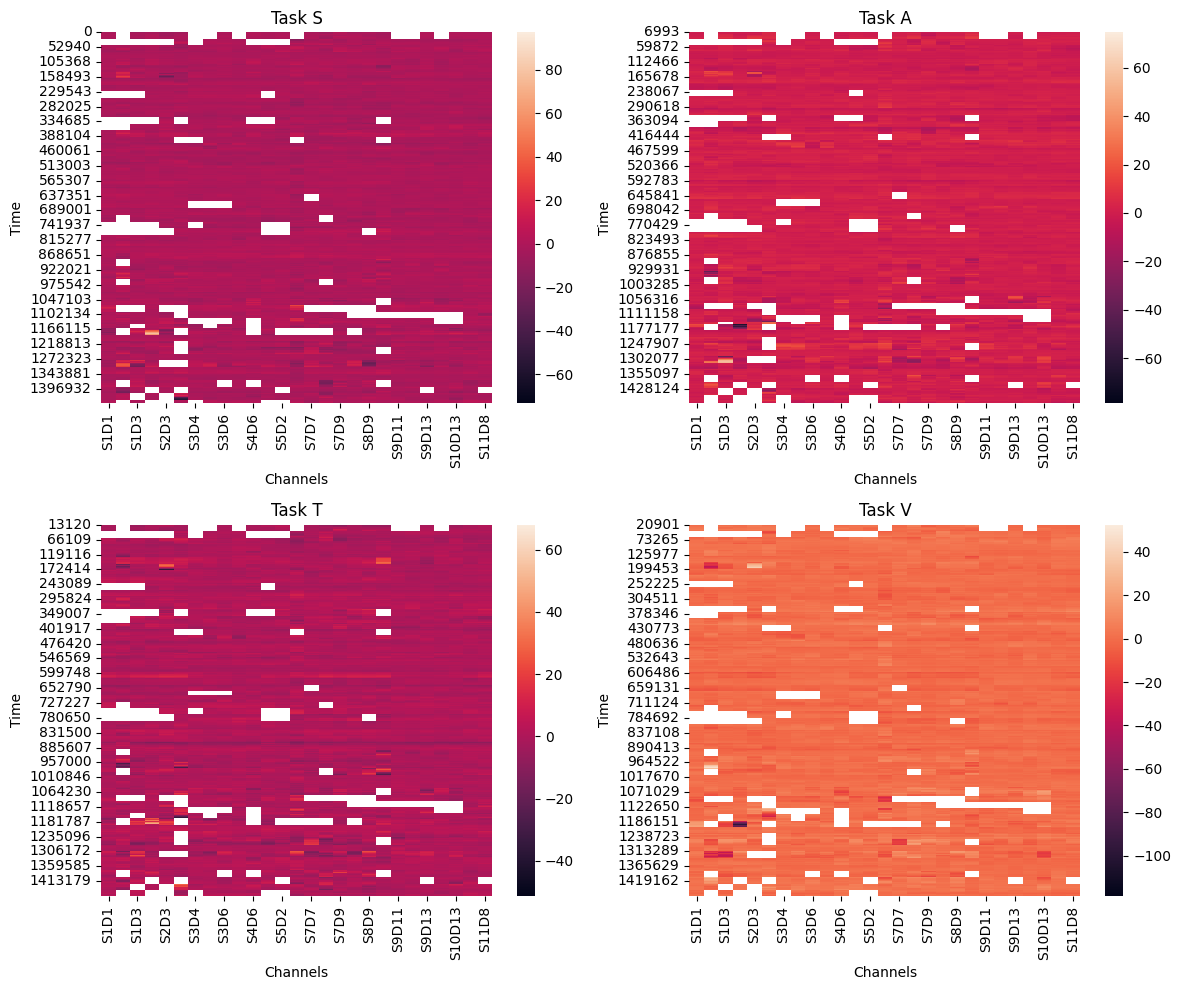

In [ ]:
plt.figure(figsize=(12,10))

for i, t in enumerate(df.task.unique()):
  print(f"Task {i}: {t}")
  plt.subplot(2,2,i+1)
  sns.heatmap(df[df.task == t][channel_names])
  plt.title(f'Task {t}')
  plt.xlabel('Channels')
  plt.ylabel('Time')

plt.tight_layout()
plt.show()

In [ ]:

df_all = df.copy()



In [ ]:
np.random.seed(42)

sel_subj = np.random.choice(df_all.subj.unique(), size=3, replace=False)
df = df_all[ df_all.subj.isin(sel_subj) ].reset_index(drop=True)
# df.drop(columns='time',inplace=True)

df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)
display(df.head())
df.subj.unique(), df.task.unique()

,subj,task,time,S1D1,S1D2,S1D3,S2D2,S2D3,S2D10,S3D4,...,S8D8,S8D9,S8D10,S9D11,S9D12,S9D13,S10D12,S10D13,S11D7,S11D8
0,18,S,2694.500000,-0.469910,-4.752409,-6.222496,-2.016846,-2.903769,-3.253732,-2.158807,...,-2.135745,-1.408032,-10.124923,-0.407616,-0.254384,2.345270,-1.937001,-0.311502,0.375485,-1.075239
1,18,S,2694.600098,-0.516263,-4.648351,-6.332409,-2.019521,-2.840042,-3.255622,-2.156405,...,-2.158288,-1.456020,-10.028012,-0.412052,-0.227003,2.282027,-1.960760,-0.302346,0.385017,-1.079106
2,18,S,2694.699951,-0.542628,-4.467700,-6.366593,-2.026592,-2.773408,-3.281226,-2.148243,...,-2.175532,-1.510419,-10.001714,-0.415793,-0.200210,2.276147,-1.979165,-0.290141,0.380120,-1.080464
3,18,S,2694.800049,-0.545029,-4.245950,-6.312380,-2.034448,-2.706362,-3.328655,-2.135519,...,-2.181487,-1.558571,-10.057871,-0.416527,-0.175544,2.328187,-1.985533,-0.273109,0.362767,-1.075437
4,18,S,2694.899902,-0.526721,-4.023611,-6.178906,-2.039846,-2.641617,-3.391424,-2.121665,...,-2.173297,-1.589370,-10.189509,-0.413483,-0.156361,2.427643,-1.976594,-0.251999,0.338381,-1.062835


(array([18, 54]), array(['S', 'A', 'T', 'V'], dtype=object))

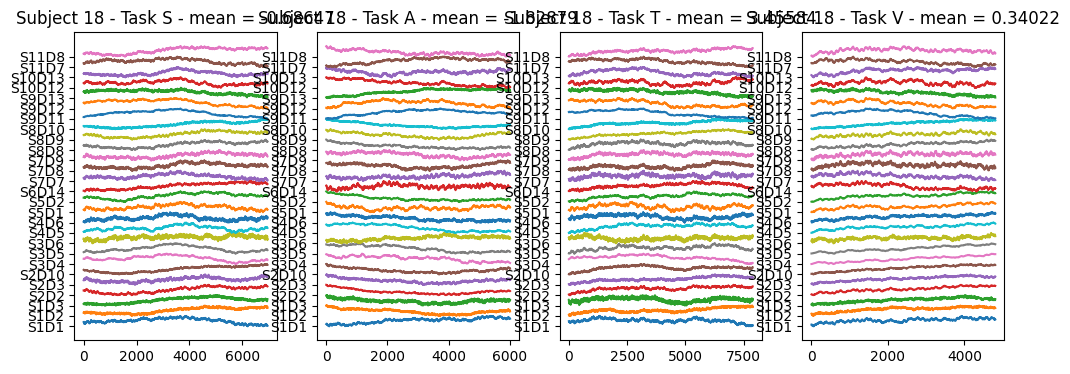

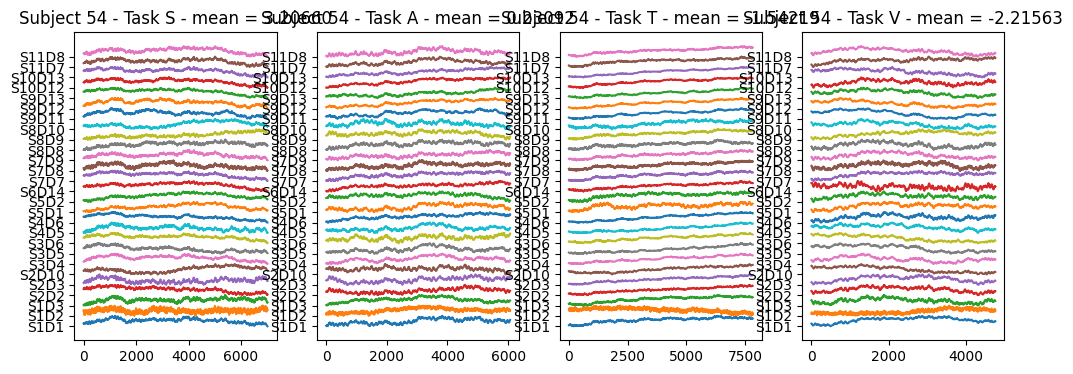

In [ ]:
from sklearn.preprocessing import minmax_scale

for s in df.subj.unique():
  plt.figure(figsize=(12,4))
  task_nr = 1
  for t in df.task.unique():

    df_temp = df[(df.task == t) & (df.subj == s)]
    df_temp = df_temp.drop(columns=['subj','time','task'])

    for coluna in range(len(df_temp.columns)):

      plt.subplot(1,len(df.task.unique()),task_nr)
      plt.plot(minmax_scale(df_temp.iloc[:,coluna])+coluna)

      plt.yticks(ticks=range(0,df_temp.shape[1]), labels=df_temp.columns[0:df_temp.shape[1]])
      plt.title(f'Subject {s} - Task {t} - mean = {df_temp.mean().mean():.5f}')
    task_nr = task_nr + 1
  plt.show()


# Filtro AR-IRLS (Autoregressive Iteratively Reweighted Least Squares) (Barker et al., 2013)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def ar_irls_channel(y, p_max=6, max_iter=25, tol=1e-4):
    """
    Aplica AR-IRLS a um canal 1D de fNIRS (Barker et al., 2013).
    Retorna o sinal limpo e os pesos atribuídos a cada instante de tempo.
    """
    y = np.asarray(y, dtype=float)
    n = len(y)

    # Pesos temporais iniciais (1.0 = amostra totalmente confiável)
    w = np.ones(n)

    # Base polinomial de tendência (constante e rampa linear)
    t = np.linspace(-1, 1, n)
    X = np.column_stack([np.ones(n), t])
    beta = np.zeros(X.shape[1])

    for iteration in range(max_iter):
        # 1. Regressão Ponderada (WLS)
        W_diag = np.sqrt(np.clip(w, 1e-4, 1.0))
        X_w = X * W_diag[:, None]
        y_w = y * W_diag
        beta_new, _, _, _ = np.linalg.lstsq(X_w, y_w, rcond=None)

        residuals = y - X @ beta_new

        # 2. Ajuste do modelo AR(p) nos resíduos
        p = min(p_max, max(2, n // 100))
        Y_lag = np.zeros((n - p, p))
        for lag in range(1, p + 1):
            Y_lag[:, lag - 1] = residuals[p - lag : n - lag]

        r_target = residuals[p:]
        w_sub = W_diag[p:]
        ar_coeffs, _, _, _ = np.linalg.lstsq(Y_lag * w_sub[:, None], r_target * w_sub, rcond=None)

        # 3. Pré-branqueamento (Filtro Inverso FIR: A(q) = [1, -a_1, -a_2, ..., -a_p])
        ar_filter = np.r_[1, -ar_coeffs]
        y_white = np.convolve(y, ar_filter, mode='same')
        X_white = np.column_stack([np.convolve(X[:, col], ar_filter, mode='same') for col in range(X.shape[1])])

        # 4. Atualização robusta dos pesos via Huber (MAD)
        res_white = y_white - X_white @ beta_new
        sigma_mad = 1.4826 * np.median(np.abs(res_white - np.median(res_white)))

        if sigma_mad < 1e-8:
            break

        u = res_white / sigma_mad
        c = 1.345  # Constante de corte de Huber (eficiência 95%)
        w_new = np.where(np.abs(u) <= c, 1.0, c / (np.abs(u) + 1e-6))

        # Critério de convergência
        if np.max(np.abs(beta_new - beta)) < tol:
            w = w_new
            break

        beta = beta_new
        w = w_new

    # Reconstrução do sinal: suaviza e remove distorções onde w < 1
    y_clean = y - (1.0 - w) * (y - X @ beta)
    return y_clean, w

def apply_ar_irls_multichannel(data_matrix, p_max=6):
    """
    Aplica AR-IRLS em todos os canais de uma matriz (n_channels, n_samples).
    """
    n_channels, n_samples = data_matrix.shape
    cleaned_data = np.zeros_like(data_matrix)
    weights_matrix = np.zeros_like(data_matrix)

    for ch in range(n_channels):
        cleaned_data[ch], weights_matrix[ch] = ar_irls_channel(data_matrix[ch], p_max=p_max)

    return cleaned_data, weights_matrix

In [ ]:
 weights_list = []

 for s in df.subj.unique():
  for t in df.task.unique():
    print(f"Subject {s} - Task {t}")

    df.iloc[df[ (df.task == t) & (df.subj == s) ].index, 3:], weights = apply_ar_irls_multichannel(np.array(df.iloc[df[ (df.task == t) & (df.subj == s) ].index, 3:]),p_max=6)
    weights_list.append(weights)

Subject 18 - Task S
Subject 18 - Task A
Subject 18 - Task T
Subject 18 - Task V
Subject 54 - Task S
Subject 54 - Task A
Subject 54 - Task T
Subject 54 - Task V


# `compute_coherence_matrix`

In [ ]:
!pip install pycwt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.0/755.0 kB 15.9 MB/s eta 0:00:00


In [ ]:
!pip install bctpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.4/110.4 kB 3.3 MB/s eta 0:00:00


In [ ]:
from scipy.signal import coherence

def compute_coherence_matrix(signals, fs=10.0):

    print('*** RUNNING COHERENCE ***')

    n = len(signals)

    matrix = np.zeros((n,n))

    for i in range(n):
        for j in range(i, n): # Compute only upper triangle (including diagonal)
            f, Cxy = coherence(signals[i], signals[j], fs)
            matrix[i,j] = np.mean(Cxy)
            if i != j: # Ensure symmetry by mirroring to the lower triangle
                matrix[j,i] = matrix[i,j]

    adj_matrix = matrix

    return adj_matrix

# `compute_correlation_matrix`

In [ ]:
import numpy as np

def compute_correlation_matrix(signals,fs=10.0):

    print('*** RUNNING CORRELATION ***')

    n = len(signals)

    matrix = np.zeros((n,n))

    for i in range(n):
        for j in range(n):

            r = np.corrcoef(signals[i], signals[j])[0,1]

            adj_matrix[i,j] = abs(r)

    return adj_matrix

# Single subj and task

In [ ]:
s = 18; t = "A";

In [ ]:
def select_subj_task(df, subj, task):
  s = subj
  t = task
  sel_df = (df.subj == s) & (df.task == t)

  channel_names = [ col for col in df.columns if col.startswith("S") ]
  signals = np.matrix( df[ sel_df ][ channel_names ] ).T

  return signals, channel_names

signals, channel_names = select_subj_task(df, s, t)

adj_matrix = compute_coherence_matrix(signals, fs=10.0)
signals.shape, adj_matrix.shape

((27, 6009), (27, 27))

## Plot matrix

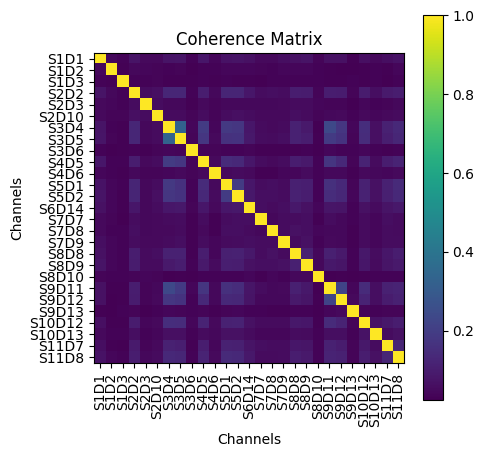

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,5))

plt.imshow(adj_matrix, cmap='viridis')
plt.colorbar()

plt.title('Coherence Matrix')
plt.xlabel('Channels')
plt.ylabel('Channels')
plt.xticks(range(len(channel_names)), channel_names, rotation=90)
plt.yticks(range(len(channel_names)), channel_names)

plt.show()





In [ ]:
print(f"Is adj_matrix symmetric: {np.array_equal(adj_matrix, adj_matrix.T)}")

Is adj_matrix symmetric: True


## `get_communities`

In [ ]:
def get_communities(channel_names, adj_matrix, density = 0.25, gamma_louvain = 1.0, all_metrics = True):
  # density = Limiar proporcional mantendo as 25% conexões mais fortes

  def get_metrics(n_null_models=20):

    # Coeficiente de Agrupamento Médio (Clustering Coefficient)
    # Requer normalização dos pesos da matriz para [0, 1]
    W_norm = bct.weight_conversion(W_thresh, 'normalize')
    clustering_coefs = bct.clustering_coef_wu(W_norm)
    C_empirical = np.mean(clustering_coefs)

    # Comprimento Médio do Caminho Característico (Characteristic Path Length - L)
    # Transforma pesos em distâncias inversas (conexão mais forte = menor distância)
    distance_matrix = bct.distance_wei(bct.weight_conversion(W_thresh, 'lengths'))[0]

    # CORREÇÃO PARA LIDAR COM VALORES inf de distance_matrix
    # Encontra o maior valor finito na matriz
    max_val = np.max(distance_matrix [np.isfinite(distance_matrix)])

    # Substitui o 'inf' por esse valor máximo (ou max_val + 1)
    distance_matrix[np.isinf(distance_matrix)] = max_val

    # Ignora distâncias infinitas se houver nós desconexos
    L_empirical = bct.charpath(distance_matrix)[0]

    # -------------------------------------------------------------
    # Small-Worldness (Sigma = (C / C_null) / (L / L_null))
    # -------------------------------------------------------------
    if False:
      C_nulls, L_nulls = [], []
      for _ in range(n_null_models):
          # Gera grafo nulo preservando a distribuição de graus e força dos nós
          W_null, _ = bct.null_model_und_sign(W_thresh)

          # Clustering do grafo nulo
          W_null_norm = bct.weight_conversion(W_null, 'normalize')
          C_nulls.append(np.mean(bct.clustering_coef_wu(W_null_norm)))

          # Path length do grafo nulo
          dist_null = bct.distance_wei(bct.weight_conversion(W_null, 'lengths'))[0]
          L_nulls.append(bct.charpath(dist_null)[0])

      gamma = C_empirical / np.mean(C_nulls)   # Razão de agrupamento
      lambda_ = L_empirical / np.mean(L_nulls) # Razão de caminho
      small_worldness_sigma = gamma / lambda_  # Sigma > 1 indica propriedade small-world

    metrics = {
        'Nodal_Strength': nodal_strength,
        'Nodal_Degree': nodal_degree,
        'Modularity_Q': modularity_Q,
        'Communities': communities,
        'Characteristic_Path_Length_L': L_empirical,
        'Clustering_Coefficient_C': C_empirical,
    #    'Small_Worldness_Sigma': small_worldness_sigma
    }

    return metrics

  # ==========================================
  # 1. Carregar Dados
  # ==========================================
  import bct # Brain Connectivity Toolbox
  from scipy.spatial.distance import squareform
  from scipy.cluster.hierarchy import linkage, leaves_list

  n_channels = len(channel_names)

  # ==========================================
  # 3. Teoria dos Grafos (BCT)
  # ==========================================
  W = adj_matrix.copy()
  W = np.clip(W, 0, 1) # Elimina valores negativos... para aplicação do Louvain em matrizes de correlação
  np.fill_diagonal(W, 0) # Zera diagonal

  W_thresh = bct.threshold_proportional(W, density, copy=True)
  A_bin = (W_thresh > 0).astype(float)

  # -------------------------------------------------------------
  # Métricas Nodais (Locais)
  # -------------------------------------------------------------
  # Grau (Degree) ou Força Nodal (Strength para matrizes ponderadas)
  nodal_strength = bct.strengths_und(W_thresh)
  nodal_degree = bct.degrees_und(A_bin)

  # if metodo.__name__ != 'compute_correlation_matrix':
  communities, modularity_Q = bct.community_louvain(W_thresh, gamma=gamma_louvain)
  # else:
  #   communities, modularity_Q = bct.modularity_louvain_und_sign(W_thresh, gamma=gamma_louvain, qtype='sta')

  # Métricas nodais e modulares
  if all_metrics:
    metrics = get_metrics()
  else:
    metrics = {}

  data_communities = pd.DataFrame({'channel': channel_names, 'communities': communities,
                       'nodal_strength': nodal_strength,
                       'nodal_degree': nodal_degree}).sort_values('communities')

  return data_communities, W_thresh, A_bin, modularity_Q, metrics



## density = 0.15, gamma_louvain = 1.0

In [ ]:
density = 0.15; gamma_louvain = 1.0

In [ ]:
signals, channel_names = select_subj_task(df, s, t)
adj_matrix = compute_coherence_matrix(signals, fs=10.0)

df_communities, W_thresh, A_bin, modularity_Q, metrics = get_communities(channel_names, adj_matrix, density = density, gamma_louvain = gamma_louvain)

print("\n--- RESULTADOS TOPOLÓGICOS ---")
print(f"Modularidade (Q): {modularity_Q:.3f}")
display(df_communities)


--- RESULTADOS TOPOLÓGICOS ---
Modularidade (Q): 0.043


,channel,communities,nodal_strength,nodal_degree
0,S1D1,1,0.000000,0.0
1,S1D2,2,0.000000,0.0
2,S1D3,3,0.000000,0.0
4,S2D3,4,0.000000,0.0
5,S2D10,5,0.000000,0.0
3,S2D2,6,0.504530,4.0
6,S3D4,6,1.941419,11.0
7,S3D5,6,1.818993,11.0
9,S4D5,6,1.204835,8.0
20,S9D11,6,1.609610,10.0


In [ ]:
for key, value in metrics.items():
  print(f"{key}: {value}")

Nodal_Strength: [0.         0.         0.         0.50452955 0.         0.
 1.94141902 1.81899251 0.         1.20483517 0.         1.67586668
 1.6477614  0.         0.         0.         0.         0.66726416
 0.31619424 0.         1.60961048 1.20239435 0.         0.91163169
 0.         0.67366955 1.01961412]
Nodal_Degree: [ 0.  0.  0.  4.  0.  0. 11. 11.  0.  8.  0. 12. 12.  0.  0.  0.  0.  6.
  3.  0. 10.  8.  0.  7.  0.  6.  8.]
Modularity_Q: 0.042963126101419793
Communities: [ 1  2  3  6  4  5  6  6  7  6  8 13 13  9 10 11 12 13 13 14  6  6 15  6
 16 13 13]
Characteristic_Path_Length_L: 16.650316291807
Clustering_Coefficient_C: 0.17801095372752407


## `get_blocks`

In [ ]:
def get_blocks(communities, adj_reordered):

  # communities = data.communities.values
  order = np.argsort(communities)

  sorted_communities_values = communities[order]

  # print("Communities sorted by index (defining blocks):")
  # print(sorted_communities_values)
  # print("\nExtracting blocks from adj_reordered:")

  current_community = -1
  start_idx = 0
  blocks_info = []

  for i, comm_id in enumerate(sorted_communities_values):
      if comm_id != current_community:
          if current_community != -1:
              end_idx = i
              blocks_info.append((current_community, start_idx, end_idx))
          current_community = comm_id
          start_idx = i
      # print(f"Channel {i} belongs to community {comm_id}")
      # print(blocks_info)

  blocks_info.append((current_community, start_idx, len(sorted_communities_values)))

  # for comm_id, start_idx, end_idx in blocks_info:
  #    print(f"\n--- Community Group G{{comm_id}} (Indices {start_idx}:{end_idx}) ---")
  #    block_matrix = adj_reordered[start_idx:end_idx, start_idx:end_idx]
  #    print(block_matrix)

  adj_matrix_blocks = np.ones_like(adj_reordered)

  for comm_id, start_idx, end_idx in blocks_info:
      adj_matrix_blocks[start_idx:end_idx, start_idx:end_idx] = adj_reordered[start_idx:end_idx, start_idx:end_idx]



  return adj_matrix_blocks, blocks_info

# adj_matrix_blocks, blocks_info = get_blocks(data.communities.values, adj_reordered)

# plt.imshow(adj_matrix_blocks, cmap='viridis')
# plt.show()

## `plot_adj_matrix_communities`

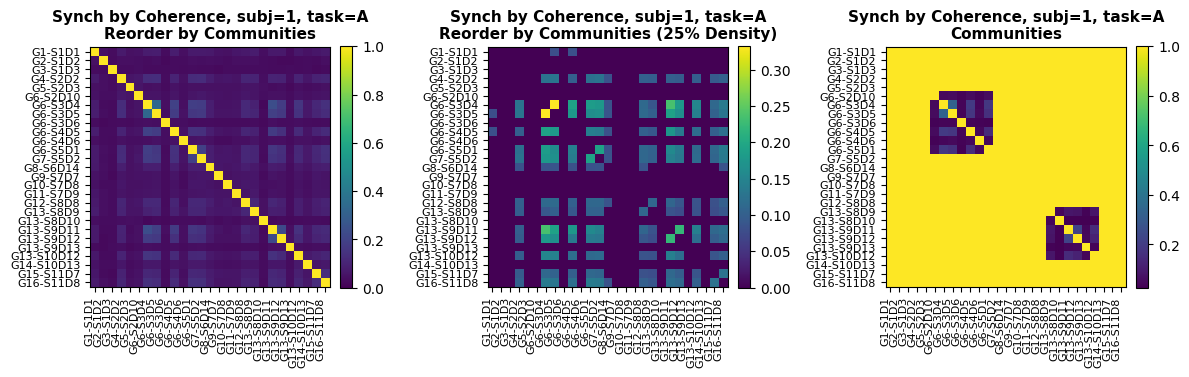

In [ ]:
def plot_adj_matrix_communities(channel_names, adj_matrix, communities, title):

  # channel_names = [ col for col in df.columns if col.startswith("S") ]
  # metric = 'Coherence'

  if not isinstance(communities, np.ndarray):
    raise ValueError("A variável 'communities' deve ser um np.array()")

  import bct # Brain Connectivity Toolbox

  n_channels = len(channel_names)

  # ==========================================
  # 3. Teoria dos Grafos (BCT)
  # ==========================================
  W = adj_matrix.copy()
  np.fill_diagonal(W, 0) # Zera diagonal

  # Limiar proporcional mantendo as 25% conexões mais fortes
  density = 0.25
  W_thresh = bct.threshold_proportional(W, density, copy=True)

  order = np.argsort(communities)

  # Reordenar todas as matrizes e rótulos
  adj_reordered = adj_matrix[np.ix_(order, order)]
  # p_reordered = p_matrix[np.ix_(order, order)]
  W_thresh_reordered = W_thresh[np.ix_(order, order)]
  # W_sig_reordered = A_bin[np.ix_(order, order)]
  labels_reordered = [channel_names[idx] for idx in order]
  groups = [communities[idx] for idx in order]
  labels_reordered = [f'G{l2}-{l1}' for l1, l2 in zip(labels_reordered, groups)]

  adj_matrix_blocks, blocks_info = get_blocks(communities, adj_reordered)

  # ==========================================
  # 5. Visualização Comparativa
  # ==========================================

  fig, axes = plt.subplots(1, 3, figsize=(12, 4))
  # axes = np.array(axes).flatten()

  # Painel 1: Coerência Reordenada
  im1 = axes[0].imshow(adj_reordered, cmap='viridis', vmin=0, vmax=1)
  # sns.heatmap(adj_reordered, ax=axes[0], cmap='viridis', vmin=0, vmax=1)
  axes[0].set_title(title + f"\nReorder by Communities",fontsize=11,weight='bold')
  axes[0].set_xticks(range(n_channels))
  axes[0].set_xticklabels(labels_reordered, rotation=90, ha='right',fontsize=8)
  axes[0].set_yticks(range(n_channels))
  # axes[0].set_yticklabels(labels_reordered, rotation=0)
  axes[0].set_yticklabels(labels_reordered,fontsize=8)
  fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)

  # Matriz Limiarizada com Blocos Modulares
  im2 = axes[1].imshow(W_thresh_reordered, cmap='viridis')
  axes[1].set_title(title + f"\nReorder by Communities ({int(density*100)}% Density)",fontsize=11,weight='bold')
  axes[1].set_xticks(range(n_channels))
  axes[1].set_xticklabels(labels_reordered, rotation=90, ha='right',fontsize=8)
  axes[1].set_yticks(range(n_channels))
  axes[1].set_yticklabels(labels_reordered,fontsize=8)
  fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)

  # Matriz Limiarizada com Blocos Modulares
  im3 = axes[2].imshow(adj_matrix_blocks, cmap='viridis')
  axes[2].set_title(title + f"\nCommunities",fontsize=11,weight='bold')
  axes[2].set_xticks(range(n_channels))
  axes[2].set_xticklabels(labels_reordered, rotation=90, ha='right',fontsize=8)
  axes[2].set_yticks(range(n_channels))
  axes[2].set_yticklabels(labels_reordered,fontsize=8)
  fig.colorbar(im3, ax=axes[2], fraction=0.046, pad=0.04)

  plt.tight_layout()
  plt.show()

  return adj_reordered, W_thresh_reordered, labels_reordered

metric = 'Coherence'
subj = s
task = t

channel_names = [ col for col in df.columns if col.startswith("S") ]
title = f"Synch by {metric}, subj={subj}, task={task}"
adj_reordered, W_thresh_reordered, labels_reordered = plot_adj_matrix_communities(channel_names, adj_matrix, df_communities.communities.values, title)

## `plot_grafo`

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

def plot_grafo(W, communities, nodal_strength, channel_names, title):
  # 1. Carregar Grafo a partir da matriz limiarizada (W_sig)
  G = nx.from_numpy_array(W)
  mapping = {i: name for i, name in enumerate(channel_names)}
  G = nx.relabel_nodes(G, mapping)

  pos = nx.spring_layout(G, seed=42, k=0.7)

  # 2. Extrair Pesos das Arestas
  edges = G.edges(data=True)
  weights = np.array([d['weight'] for u, v, d in edges])

  # 3. Criar Dicionário com Rótulos Numéricos das Arestas (ex: "0.98")
  edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in edges}

  # 4. Configurar Nós
  max_str = np.max(nodal_strength) if np.max(nodal_strength) > 0 else 1.0
  node_sizes = 600 + 1400 * (nodal_strength / max_str)
  unique_comms = np.unique(communities)
  cmap_nodes = plt.get_cmap('tab10', len(unique_comms))
  node_colors = [cmap_nodes(np.where(unique_comms == comm)[0][0]) for comm in communities]

  plt.figure(figsize=(9, 7))

  # Desenhar Nós e Rótulos dos Canais
  nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, edgecolors='black', linewidths=1.5)
  nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold')

  # Desenhar Arestas (com espessura e gradiente de cor variando com o peso)
  edge_widths = weights * 4.5
  nx.draw_networkx_edges(
      G, pos,
      width=edge_widths,
      edge_color=weights,
      edge_cmap=plt.cm.Blues,
      edge_vmin=0.0,
      edge_vmax=1.0,
      alpha=0.85
  )

  # Desenhar os Valores Numéricos nas Arestas
  nx.draw_networkx_edge_labels(
      G, pos,
      edge_labels=edge_labels,
      font_size=8,
      font_color='darkblue',
      bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.8)
  )

  # Adicionar Barra de Cores (Colorbar) para a Força das Arestas
  sm = plt.cm.ScalarMappable(cmap=plt.cm.Blues, norm=plt.Normalize(vmin=0.0, vmax=1.0))
  sm.set_array([])
  cbar = plt.colorbar(sm, ax=plt.gca(), fraction=0.046, pad=0.04)
  cbar.set_label('Connection Strengths', rotation=270, labelpad=15)

  # Adicionar legenda de módulos/comunidades
  for comm_id in unique_comms:
      plt.scatter([], [], color=cmap_nodes(np.where(unique_comms == comm_id)[0][0]),
                  label=f'Comm = {comm_id}', s=100, edgecolors='black')

  plt.legend(scatterpoints=1, frameon=True, loc='upper left', title="Communities", fontsize=9)

  plt.title(title, fontsize=12, pad=15, weight='bold')
  plt.axis('off')
  plt.tight_layout()
  plt.show()

  return

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

def plot_grafo_selected(W, communities, nodal_strength, channel_names, title, unconnected=True, outcommunities=True):
  # 1. Carregar Grafo a partir da matriz limiarizada (W_sig)
  G = nx.from_numpy_array(W)
  mapping = {i: name for i, name in enumerate(channel_names)}
  G = nx.relabel_nodes(G, mapping)

  # --- MODIFICAÇÕES AQUI: Começo da lógica de filtragem ---
  # Crie uma máscara booleana para os nós a serem mantidos
  nodes_to_keep_mask = np.ones(len(channel_names), dtype=bool)

  if not unconnected:
      # Remove nós com força nodal zero (sem conexões)
      nodes_to_keep_mask = nodes_to_keep_mask & (nodal_strength > 0)

  if not outcommunities:
      # Identifica comunidades com apenas um membro
      unique_comms_in_full_data, counts = np.unique(communities, return_counts=True)
      singleton_comms = unique_comms_in_full_data[counts == 1]

      # Crie uma máscara para nós que NÃO estão em comunidades de um único membro
      not_singleton_comm_mask = ~np.isin(communities, singleton_comms)
      nodes_to_keep_mask = nodes_to_keep_mask & not_singleton_comm_mask

  # Obter os nomes dos nós a serem mantidos
  filtered_node_names = channel_names[nodes_to_keep_mask]

  # Criar um subgrafo apenas com os nós filtrados
  G_filtered = G.subgraph(filtered_node_names)

  # Filtrar outras informações para o plot
  filtered_communities = communities[nodes_to_keep_mask]
  filtered_nodal_strength = nodal_strength[nodes_to_keep_mask]
  # --- MODIFICAÇÕES AQUI: Fim da lógica de filtragem ---

  # Recalcular pos para o grafo filtrado
  pos = nx.spring_layout(G_filtered, seed=42, k=0.7)

  # 2. Extrair Pesos das Arestas (agora do grafo filtrado)
  edges = G_filtered.edges(data=True)
  weights = np.array([d['weight'] for u, v, d in edges])

  # 3. Criar Dicionário com Rótulos Numéricos das Arestas (ex: "0.98")
  edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in edges}

  # 4. Configurar Nós
  # --- MODIFICAÇÕES AQUI: Usar dados filtrados para cor e tamanho dos nós ---
  max_str = np.max(filtered_nodal_strength) if np.max(filtered_nodal_strength) > 0 else 1.0
  node_sizes = 600 + 1400 * (filtered_nodal_strength / max_str)
  unique_comms_for_plot = np.unique(filtered_communities)
  cmap_nodes = plt.get_cmap('tab10', len(unique_comms_for_plot))
  node_colors = [cmap_nodes(np.where(unique_comms_for_plot == comm)[0][0]) for comm in filtered_communities]
  # --- MODIFICAÇÕES AQUI: Fim do uso de dados filtrados ---

  plt.figure(figsize=(9, 7))

  # Desenhar Nós e Rótulos dos Canais (usando G_filtered)
  # --- MODIFICAÇÕES AQUI: Passar G_filtered.nodes para draw_networkx_nodes e draw_networkx_labels ---
  nx.draw_networkx_nodes(G_filtered, pos, node_color=node_colors, node_size=node_sizes, edgecolors='black', linewidths=1.5)
  nx.draw_networkx_labels(G_filtered, pos, font_size=9, font_weight='bold')
  # --- MODIFICAÇÕES AQUI: Fim das mudanças para G_filtered ---

  # --- MODIFICAÇÕES AQUI: Início da correção para 'edge_widths' ---
  edge_widths = np.array([]) # Initialize edge_widths to ensure it's always defined
  if len(weights) > 0:
      edge_widths = weights * 4.5
      nx.draw_networkx_edges(
          G_filtered, pos,
          width=edge_widths,
          edge_color=weights,
          edge_cmap=plt.cm.Blues,
          edge_vmin=0.0,
          edge_vmax=1.0,
          alpha=0.85
      )
      # Desenhar os Valores Numéricos nas Arestas (somente se houver arestas para desenhar)
      nx.draw_networkx_edge_labels(
          G_filtered, pos,
          edge_labels=edge_labels,
          font_size=8,
          font_color='darkblue',
          bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.8)
      )
  # --- MODIFICAÇÕES AQUI: Fim da correção para 'edge_widths' ---

  # Adicionar Barra de Cores (Colorbar) para a Força das Arestas
  sm = plt.cm.ScalarMappable(cmap=plt.cm.Blues, norm=plt.Normalize(vmin=0.0, vmax=1.0))
  sm.set_array([])
  cbar = plt.colorbar(sm, ax=plt.gca(), fraction=0.046, pad=0.04)
  cbar.set_label('Connection Strengths', rotation=270, labelpad=15)

  # Adicionar legenda de módulos/comunidades
  # --- MODIFICAÇÕES AQUI: Usar unique_comms_for_plot para a legenda ---
  for comm_id in unique_comms_for_plot:
      plt.scatter([], [], color=cmap_nodes(np.where(unique_comms_for_plot == comm_id)[0][0]),
                  label=f'Comm = {comm_id}', s=100, edgecolors='black')
  # --- MODIFICAÇÕES AQUI: Fim das mudanças para unique_comms_for_plot ---

  plt.legend(scatterpoints=1, frameon=True, loc='upper left', title="Communities", fontsize=9)

  plt.title(title, fontsize=12, pad=15, weight='bold')
  plt.axis('off')
  plt.tight_layout()
  plt.show()

  return

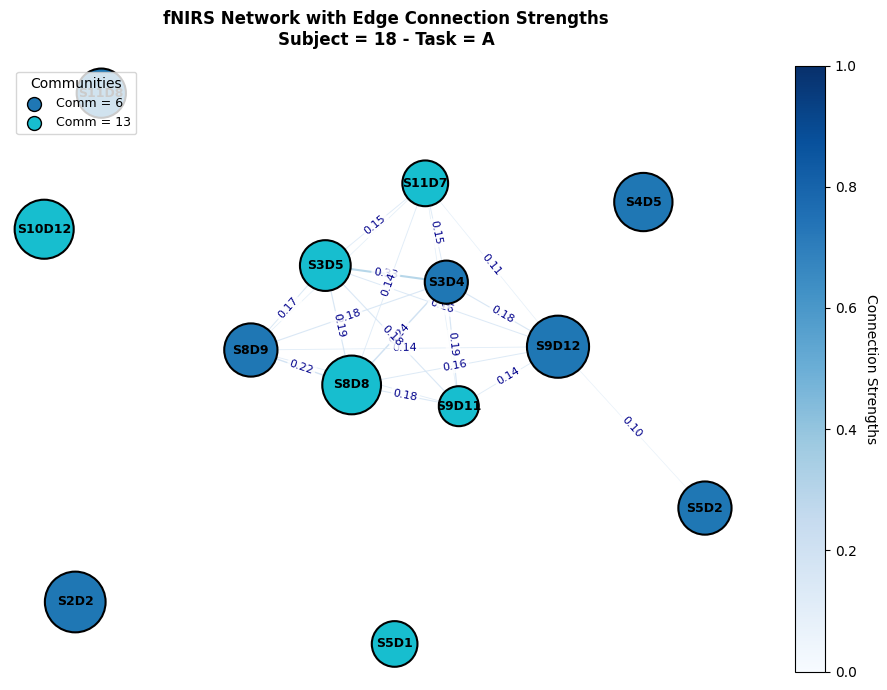

In [ ]:
communities = df_communities.communities.values
nodal_strength = df_communities.nodal_strength.values
channel_names = df_communities.channel.values

title = f"fNIRS Network with Edge Connection Strengths\nSubject = {s} - Task = {t}"
plot_grafo_selected(W_thresh, communities, nodal_strength, channel_names, title, unconnected=False, outcommunities=False)

# density = 0.25; gamma_louvain = 1.0

Valores de modularidade $Q$ entre **0.35 e 0.45 não são baixos**; na literatura de redes cerebrais e neuroimagem funcional (fMRI e fNIRS), essa é exatamente a faixa típica observada para cérebros saudáveis e redes bem segregadas.

O referencial clássico da física estatística e teoria dos grafos (proposto originalmente por Newman e Girvan) estabelece que redes com estrutura comunitária forte e modular geralmente apresentam:

$$0.3 \le Q \le 0.7$$

Valores acima de $0.7$ ou $0.8$ são extremamente raros no córtex, pois o cérebro opera em um equilíbrio contínuo entre **segregação funcional** (módulos especializados) e **integração global** (vias de comunicação rápida e *hubs* conectando módulos distantes). Se $Q$ se aproximasse de $1.0$, a rede seria composta por ilhas completamente desconexas, sem nenhuma transferência de informação global.

---

### Como interpretar as faixas de $Q$ em neurociência funcional

| Faixa de $Q$ | Interpretação Topológica | Contexto em fNIRS |
| --- | --- | --- |
| **$Q < 0.2$** | Estrutura aleatória ou homogênea | Sem modularidade clara; rede muito densa ou dominada por ruído sistêmico global. |
| **$0.3 \le Q \le 0.5$** | **Modularidade funcional típica** | Estrutura modular equilibrada com integração entre subsistemas (*small-world* funcional). |
| **$0.5 < Q \le 0.7$** | Alta segregação | Módulos bastante autônomos e densos; comum com densidades de corte mais restritas (top 10%–15%). |
| **$Q > 0.75$** | Hipersegregação / Desconexão | Rede fragmentada em componentes quase isolados; risco de limiar excessivamente agressivo. |

---

### Como testar se o seu $Q = 0.36$ ou $0.45$ é estatisticamente significativo

Um valor isolado de $Q$ não responde, por si só, se a partição é produto da biologia ou do mero acaso da topologia da rede. O procedimento padrão para avaliar a **significância estatística** é contrastar o $Q$ empírico contra um conjunto de **redes nulas substitutas (*surrogate null models*)**:

1. **Geração de redes nulas:** Crie 100 ou 1.000 redes aleatórias a partir da sua rede limiarizada, preservando o número de nós, o número de arestas e a sequência de graus/forças dos canais (função `bct.randmio_und` da BCT).
2. **Execução da detecção:** Calcule a modularidade máxima $Q_{\text{nulo}}$ para cada uma das redes aleatórias com o mesmo algoritmo e parâmetro $\gamma$.
3. **Teste de hipótese / $Z$-score:**

$$Z_Q = \frac{Q_{\text{empírico}} - \mu(Q_{\text{nulo}})}{\sigma(Q_{\text{nulo}})}$$


* Se $Z_Q > 2.0$ (ou $p < 0.05$ na distribuição empírica nula), a modularidade observada é estatisticamente significativa e não decorre apenas da densidade de conexões da montagem.

### Fatores que afetam o valor absoluto de $Q$ no seu ensaio

1. **Densidade da Matriz:** Se o corte preserva 30% a 40% das arestas mais fortes, o piso de conectividade global puxa $Q$ para a faixa de $0.30$ a $0.40$. Com cortes mais estritos (ex.: 15%), $Q$ sobe naturalmente para a faixa de $0.50$ a $0.60$.
2. **Parâmetro de Resolução ($\gamma$):** Valores de $\gamma > 1$ penalizam o modelo nulo, o que costuma reduzir a magnitude numérica pura da métrica $Q$, mesmo que produza divisões anátomo-funcionais biologicamente mais precisas.
3. **Número Total de Canais:** Montagens fNIRS restritas (ex.: 16 a 32 canais) têm diâmetro topológico menor do que parcipações de fMRI de cérebro total (onde há 100 a 400 nós). Quanto menor a rede, mais estreita tende a ser a margem para modularidades extremas.

In [ ]:
metodo = compute_coherence_matrix; density = 0.20; gamma_louvain = 1.0


Subject 18 - Task S
*** RUNNING COHERENCE ***

--- RESULTADOS TOPOLÓGICOS ---
Modularidade (Q): 0.436


,channel
communities,
1,5
2,6
4,9
5,3
6,3


,channel,communities,nodal_strength,nodal_degree
3,S2D2,1,1.066882,6.0
2,S1D3,1,0.461471,4.0
13,S6D14,1,1.153705,7.0
14,S7D7,1,1.692802,10.0
22,S9D13,1,0.831862,4.0
7,S3D5,2,0.345990,3.0
6,S3D4,2,1.037880,6.0
8,S3D6,2,0.604668,3.0
12,S5D2,2,0.679908,6.0
10,S4D6,2,0.883669,5.0


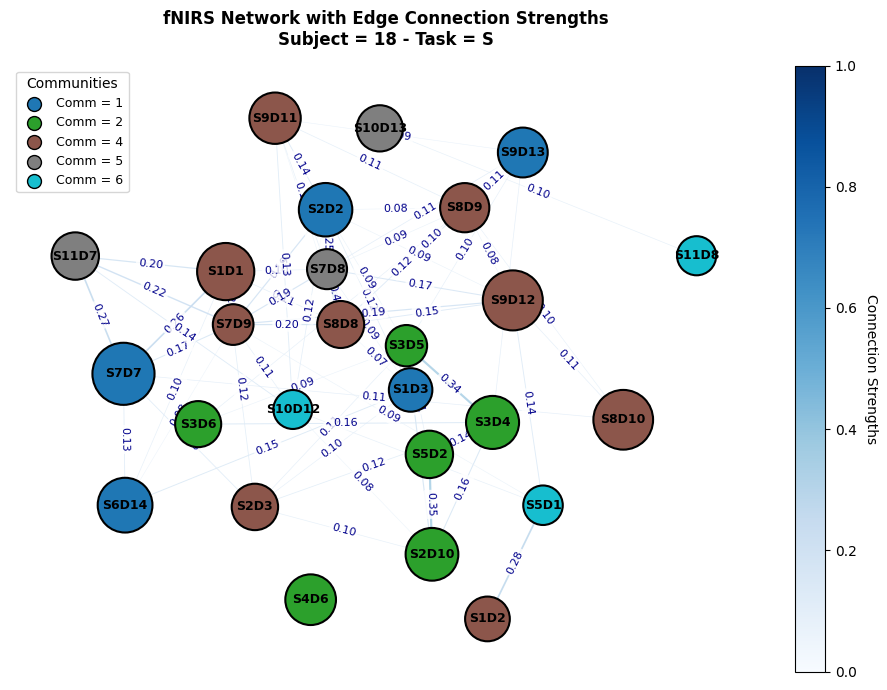


Subject 18 - Task A
*** RUNNING COHERENCE ***

--- RESULTADOS TOPOLÓGICOS ---
Modularidade (Q): 0.343


,channel
communities,
1,6
2,10
3,2
4,9


,channel,communities,nodal_strength,nodal_degree
3,S2D2,1,0.196845,2.0
2,S1D3,1,0.396356,3.0
4,S2D3,1,0.177260,2.0
10,S4D6,1,0.617191,6.0
15,S7D8,1,0.306971,3.0
24,S10D13,1,0.562501,5.0
8,S3D6,2,0.532287,5.0
9,S4D5,2,0.370687,3.0
13,S6D14,2,0.715456,5.0
12,S5D2,2,0.657843,5.0


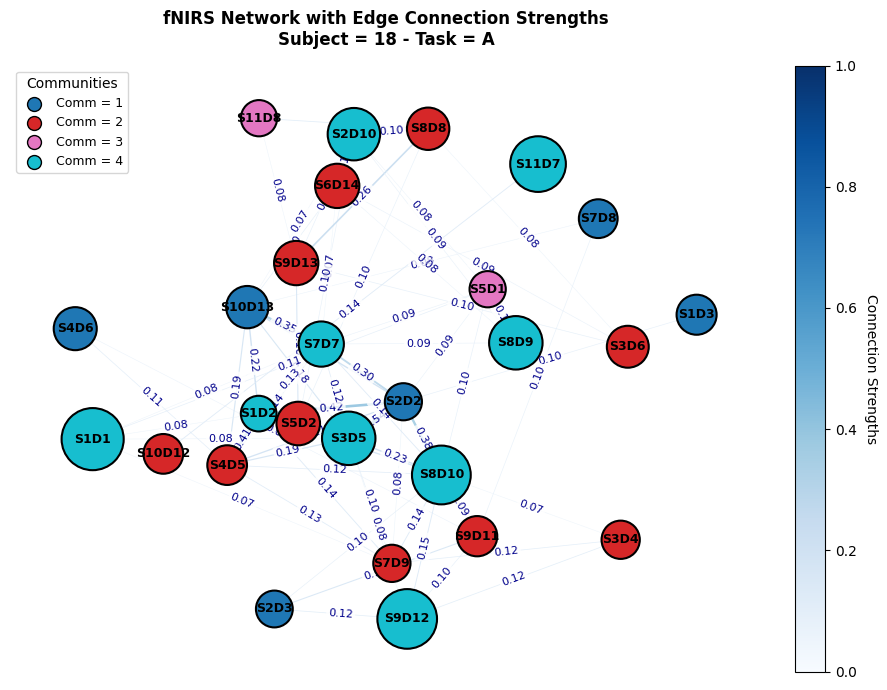


Subject 18 - Task T
*** RUNNING COHERENCE ***

--- RESULTADOS TOPOLÓGICOS ---
Modularidade (Q): 0.480


,channel
communities,
2,3
5,10
7,10


,channel,communities,nodal_strength,nodal_degree
6,S3D4,2,0.339364,2.0
11,S5D1,2,0.314878,2.0
26,S11D8,2,0.283977,2.0
3,S2D2,5,1.068460,8.0
7,S3D5,5,0.921440,6.0
4,S2D3,5,0.924361,8.0
9,S4D5,5,0.334513,3.0
21,S9D12,5,1.902601,8.0
25,S11D7,5,0.110647,1.0
18,S8D9,5,1.145313,6.0


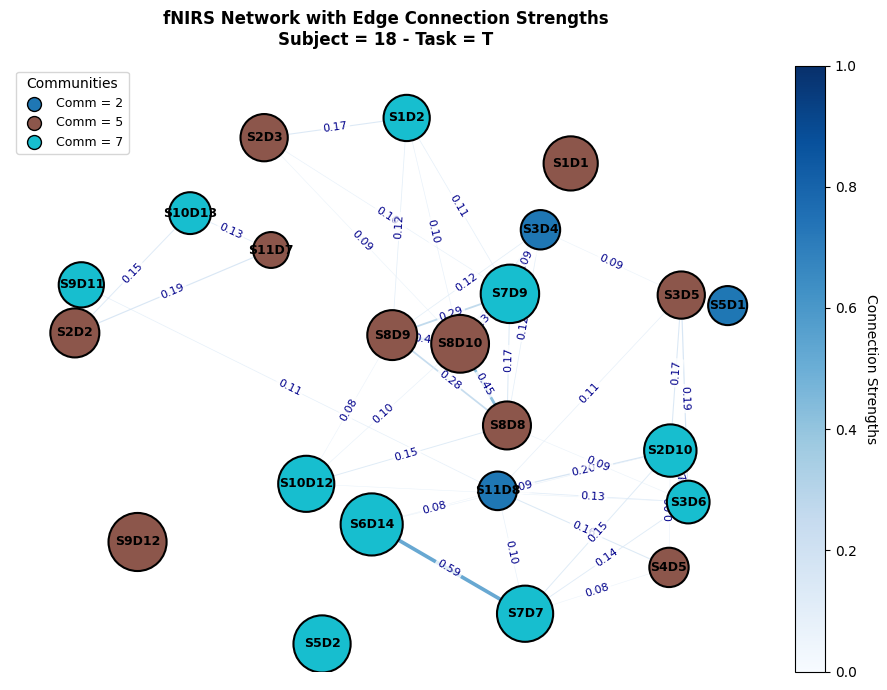


Subject 18 - Task V
*** RUNNING COHERENCE ***

--- RESULTADOS TOPOLÓGICOS ---
Modularidade (Q): 0.497


,channel
communities,
1,3
2,10
4,9
5,3


,channel,communities,nodal_strength,nodal_degree
1,S1D2,1,0.283196,2.0
2,S1D3,1,0.288196,2.0
6,S3D4,1,0.130297,1.0
0,S1D1,2,1.303672,7.0
3,S2D2,2,1.543331,9.0
7,S3D5,2,0.793420,5.0
9,S4D5,2,1.236726,7.0
8,S3D6,2,0.398716,3.0
15,S7D8,2,1.253678,7.0
22,S9D13,2,0.589386,5.0


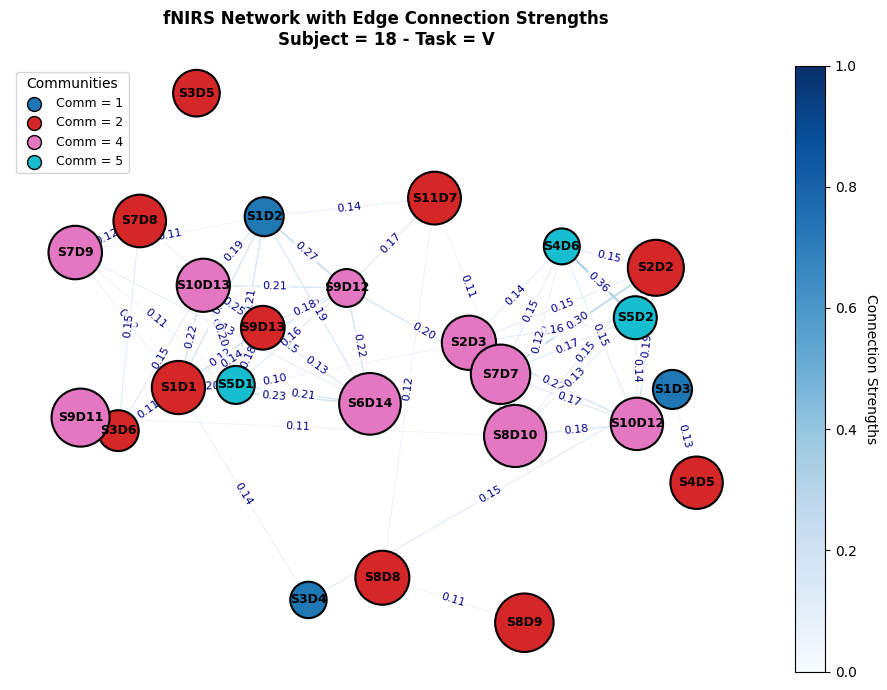

In [ ]:


for s in [18]: # df.subj.unique():
  for t in df.task.unique():
    print(70*'=','\n')
    print(f"Subject {s} - Task {t}")

    signals, channel_names = select_subj_task(df, s, t)
    adj_matrix = metodo(signals, fs=10.0)

    df_communities, W_thresh, A_bin, modularity_Q, metrics = get_communities(channel_names, adj_matrix, density = density, gamma_louvain = gamma_louvain)

    print("\n--- RESULTADOS TOPOLÓGICOS ---")

    print(f"Modularidade (Q): {modularity_Q:.3f}")
    display(df_communities[ df_communities.nodal_degree > 0 ].groupby('communities').channel.count())
    print()
    display(df_communities[ df_communities.nodal_degree > 0 ])

    # title = f"Synch by {metric}, subj={subj}, task={task}"
    # adj_reordered, W_thresh_reordered, labels_reordered = plot_adj_matrix_communities(channel_names, adj_matrix, df_communities.communities.values, title)

    communities = df_communities.communities.values
    nodal_strength = df_communities.nodal_strength.values
    channel_names = df_communities.channel.values

    title = f"fNIRS Network with Edge Connection Strengths\nSubject = {s} - Task = {t}"
    plot_grafo_selected(W_thresh, communities, nodal_strength, channel_names, title, unconnected=False, outcommunities=False)


# density = 0.15; gamma_louvain = 1.0

In [ ]:
metodo = compute_correlation_matrix


Subject 54 - Task S
*** RUNNING CORRELATION ***

--- RESULTADOS TOPOLÓGICOS ---
Modularidade (Q): 0.136


,channel
communities,
4,2
5,10
7,3
8,7


,channel,communities,nodal_strength,nodal_degree
5,S2D10,4,0.945763,1.0
19,S8D10,4,0.945763,1.0
6,S3D4,5,11.064335,13.0
7,S3D5,5,1.608715,2.0
3,S2D2,5,6.732001,8.0
14,S7D7,5,11.508558,13.0
10,S4D6,5,8.592638,10.0
15,S7D8,5,4.025255,5.0
8,S3D6,5,8.442732,10.0
20,S9D11,5,3.337221,4.0


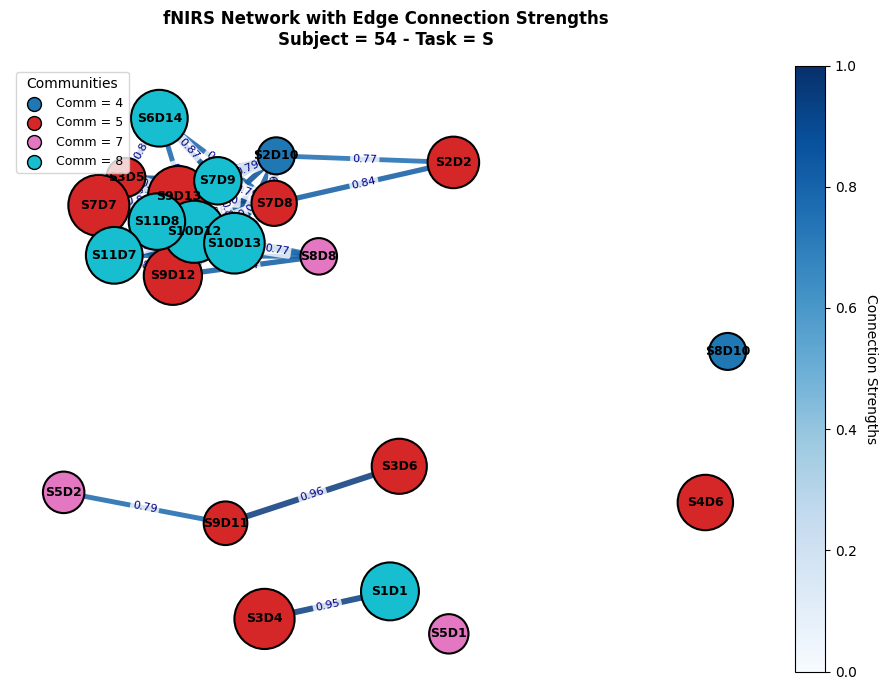


Subject 54 - Task A
*** RUNNING CORRELATION ***

--- RESULTADOS TOPOLÓGICOS ---
Modularidade (Q): 0.360


,channel
communities,
1,3
2,10
4,4
5,9


,channel,communities,nodal_strength,nodal_degree
3,S2D2,1,1.726230,2.0
4,S2D3,1,1.717871,2.0
11,S5D1,1,8.302613,10.0
1,S1D2,2,0.812149,1.0
2,S1D3,2,3.246033,4.0
6,S3D4,2,7.633672,9.0
7,S3D5,2,5.173078,6.0
0,S1D1,2,8.551025,10.0
15,S7D8,2,10.742770,13.0
9,S4D5,2,3.475882,4.0


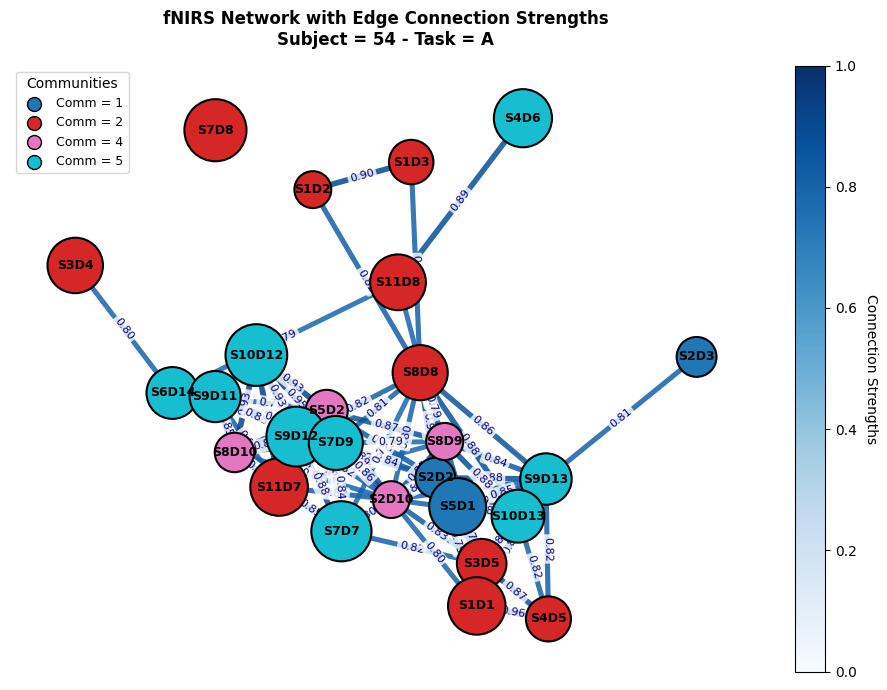


Subject 54 - Task T
*** RUNNING CORRELATION ***

--- RESULTADOS TOPOLÓGICOS ---
Modularidade (Q): 0.098


,channel
communities,
4,11
5,2
10,7


,channel,communities,nodal_strength,nodal_degree
3,S2D2,4,11.785065,12.0
6,S3D4,4,10.810474,11.0
4,S2D3,4,12.723181,13.0
10,S4D6,4,11.787442,12.0
8,S3D6,4,10.822540,11.0
15,S7D8,4,0.971066,1.0
21,S9D12,4,12.819834,13.0
22,S9D13,4,10.818636,11.0
24,S10D13,4,11.824689,12.0
20,S9D11,4,12.780231,13.0


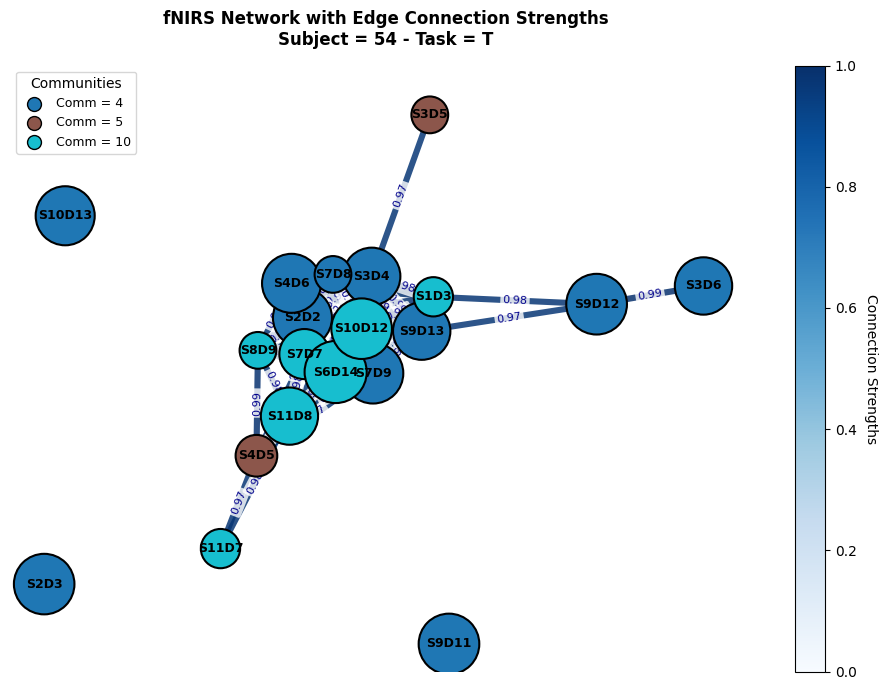


Subject 54 - Task V
*** RUNNING CORRELATION ***

--- RESULTADOS TOPOLÓGICOS ---
Modularidade (Q): 0.484


,channel
communities,
1,5
2,9
3,12


,channel,communities,nodal_strength,nodal_degree
0,S1D1,1,4.313841,5.0
11,S5D1,1,5.841619,7.0
14,S7D7,1,3.519621,4.0
18,S8D9,1,3.418414,4.0
25,S11D7,1,1.615489,2.0
12,S5D2,2,7.306911,9.0
10,S4D6,2,6.577194,8.0
2,S1D3,2,6.680882,8.0
15,S7D8,2,5.730248,7.0
17,S8D8,2,4.279747,5.0


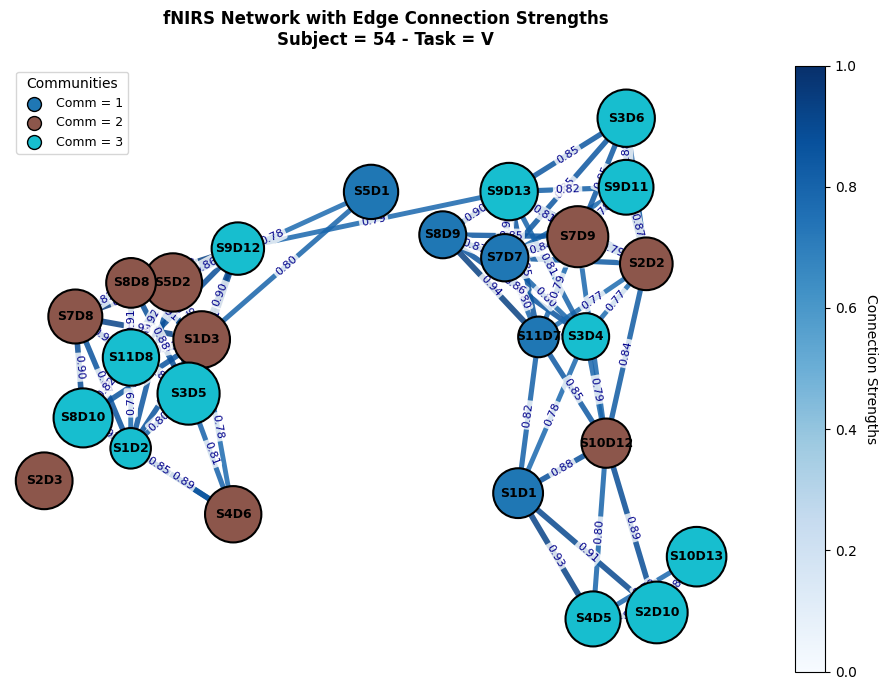

In [ ]:
density = 0.25; gamma_louvain = 1.0

for s in [54]: # df.subj.unique():
  for t in df.task.unique():
    print(70*'=','\n')
    print(f"Subject {s} - Task {t}")

    signals, channel_names = select_subj_task(df, s, t)
    adj_matrix = metodo(signals, fs=10.0)

    df_communities, W_thresh, A_bin, modularity_Q, metrics = get_communities(channel_names, adj_matrix, density = density, gamma_louvain = gamma_louvain)

    print("\n--- RESULTADOS TOPOLÓGICOS ---")

    print(f"Modularidade (Q): {modularity_Q:.3f}")
    display(df_communities[ df_communities.nodal_degree > 0 ].groupby('communities').channel.count())
    print()
    display(df_communities[ df_communities.nodal_degree > 0 ])

    # title = f"Synch by {metric}, subj={subj}, task={task}"
    # adj_reordered, W_thresh_reordered, labels_reordered = plot_adj_matrix_communities(channel_names, adj_matrix, df_communities.communities.values, title)

    communities = df_communities.communities.values
    nodal_strength = df_communities.nodal_strength.values
    channel_names = df_communities.channel.values

    title = f"fNIRS Network with Edge Connection Strengths\nSubject = {s} - Task = {t}"
    plot_grafo_selected(W_thresh, communities, nodal_strength, channel_names, title, unconnected=False, outcommunities=False)


# Louvain com Consenso Modular

In [ ]:
# -------------------------------------------------------------
# 1. Pipeline de Consenso para um dado Gamma (ex: gamma = 1.2)
# -------------------------------------------------------------
def compute_modularity(adj_matrix, ci, gamma=1.0):
    """
    Calcula o valor exato da modularidade Q para uma partição conhecida `ci`.
    Compatível com grafos ponderados não-direcionados.
    """
    ci = np.array(ci)
    k = np.sum(adj_matrix, axis=1)  # Grau/força de cada nó
    m2 = np.sum(k)                  # 2m: soma total dos pesos

    if m2 == 0:
        return 0.0

    # Matriz delta de Kronecker: delta[i, j] = 1 se ci[i] == ci[j], senão 0
    delta = np.equal.outer(ci, ci).astype(float)

    # Modelo nulo de Newman-Girvan: (k_i * k_j) / (2m)
    null_model = gamma * np.outer(k, k) / m2

    # Q = (1 / 2m) * sum((A_ij - gamma * null_ij) * delta_ij)
    Q = np.sum((adj_matrix - null_model) * delta) / m2
    return float(Q)

def run_consensus_louvain(adj_matrix, gamma=1.0, n_iter=100, tau=0.4):

    n_nodes = adj_matrix.shape[0]

    # 1. Matriz 2D para armazenar todas as partições: shape (n_nodes, n_iter)
    all_partitions = np.zeros((n_nodes, n_iter), dtype=int)

    for it in range(n_iter):
        ci, _ = bct.community_louvain(adj_matrix, gamma=gamma)
        all_partitions[:, it] = ci

    # 2. Matriz de concordância absoluta (número de co-ocorrências)
    agreement_matrix = bct.agreement(all_partitions)

    # 3. Limiar tau escalado para o número de iterações
    # Se tau=0.4 e n_iter=100, corta co-ocorrências abaixo de 40
    tau_scaled = tau * n_iter

    # bct.consensus_und retorna apenas o vetor 1D com os rótulos de módulo
    consensus_ci = bct.consensus_und(
        agreement_matrix,
        tau=tau_scaled,
        reps=n_iter
    )

    # 4. Avalia Q na matriz original limiarizada
    q_consensus = compute_modularity(adj_matrix, consensus_ci, gamma=gamma)

    return consensus_ci, q_consensus, agreement_matrix


import bct # Brain Connectivity Toolbox
density = 0.25
W = adj_matrix.copy()
np.fill_diagonal(W, 0) # Zera diagonal

W_thresh = bct.threshold_proportional(W, density, copy=True)

# -------------------------------------------------------------
# 2. Varredura de Resolução (Gamma Tuning)
# -------------------------------------------------------------
gamma_values = np.linspace(0.5, 2.5, 21)
num_communities = []
modularity_scores = []
cis = []

for g in gamma_values:
    ci, q, _ = run_consensus_louvain(W_thresh, gamma=g, n_iter=50, tau=0.35)
    num_communities.append(len(np.unique(ci)))
    modularity_scores.append(q)
    cis.append(ci)

# Exibição dos resultados da varredura
for g, k, q, ci in zip(gamma_values, num_communities, modularity_scores, cis):
    print(f"Gamma: {g:.2f} | Módulos encontrados: {k:2d} | Q: {q:.4f} | ci: {ci}")

Gamma: 0.50 | Módulos encontrados:  3 | Q: 0.7118 | ci: [1. 1. 1. 2. 2. 2. 2. 2. 3. 2.]
Gamma: 0.60 | Módulos encontrados:  3 | Q: 0.6542 | ci: [1. 1. 1. 2. 2. 2. 2. 2. 3. 2.]
Gamma: 0.70 | Módulos encontrados:  3 | Q: 0.5966 | ci: [1. 1. 1. 2. 2. 2. 2. 2. 3. 2.]
Gamma: 0.80 | Módulos encontrados:  3 | Q: 0.5389 | ci: [1. 1. 1. 2. 2. 2. 2. 2. 3. 2.]
Gamma: 0.90 | Módulos encontrados:  3 | Q: 0.4813 | ci: [1. 1. 1. 2. 2. 2. 2. 2. 3. 2.]
Gamma: 1.00 | Módulos encontrados:  3 | Q: 0.4236 | ci: [1. 1. 1. 2. 2. 2. 2. 2. 3. 2.]
Gamma: 1.10 | Módulos encontrados:  3 | Q: 0.3660 | ci: [1. 1. 1. 2. 2. 2. 2. 2. 3. 2.]
Gamma: 1.20 | Módulos encontrados:  3 | Q: 0.3084 | ci: [1. 1. 1. 2. 2. 2. 2. 2. 3. 2.]
Gamma: 1.30 | Módulos encontrados:  4 | Q: 0.2689 | ci: [1. 1. 1. 2. 2. 3. 2. 3. 4. 3.]
Gamma: 1.40 | Módulos encontrados:  4 | Q: 0.2342 | ci: [1. 1. 1. 2. 2. 3. 2. 3. 4. 3.]
Gamma: 1.50 | Módulos encontrados:  4 | Q: 0.1996 | ci: [1. 1. 1. 2. 2. 3. 2. 3. 4. 3.]
Gamma: 1.60 | Módulos encontrado